In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load fish dataset

df = pd.read_csv("fish-data.csv")

# Display first rows
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


In [5]:


df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [6]:
text_columns = df.select_dtypes(include=["object"]).columns

text_columns

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_8233/3121466753.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=["object"]).columns


Index(['Species'], dtype='str')

In [7]:
# Combine text fields into one column

df["text_data"] = df[text_columns].astype(str).apply(
    lambda x: " ".join(x), axis=1
)

df["text_data"].head()

0    Bream
1    Bream
2    Bream
3    Bream
4    Bream
Name: text_data, dtype: str

In [8]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    
    # Remove numbers and symbols
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words 
        if word not in stop_words
    ]
    
    return " ".join(words)


df["clean_text"] = df["text_data"].apply(clean_text)

df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,text_data,clean_text
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,Bream,bream
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,Bream,bream
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,Bream,bream
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,Bream,bream
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,Bream,bream


In [9]:
tfidf = TfidfVectorizer(
    max_features=100
)

text_features = tfidf.fit_transform(
    df["clean_text"]
)

text_features.shape

(159, 7)

In [10]:
numeric_features = df.select_dtypes(
    include=["int64","float64"]
)

numeric_features.head()

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340


In [11]:
scaler = StandardScaler()

scaled_numeric = scaler.fit_transform(
    numeric_features
)

In [12]:
from scipy.sparse import hstack

# Combine fish measurements with text information

combined_features = hstack(
    [
        scaled_numeric,
        text_features
    ]
)

combined_features.shape

(159, 13)

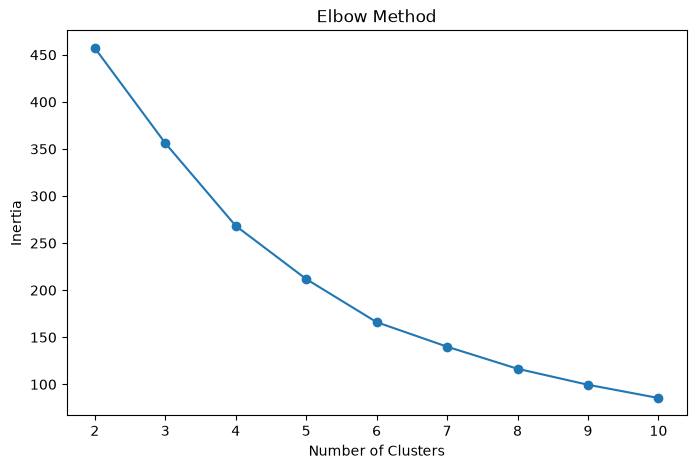

In [13]:
inertia = []

for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(combined_features)
    
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [14]:
df.to_csv(
    "fish_data_kmeans_nlp_results.csv",
    index=False
)